# Heavy-Tailed Financial Market Simulation

This notebook compares **Geometric Brownian Motion (GBM)** and the **Variance Gamma (VG)** Lévy process as models for asset returns.

**Motivation:** Standard RL trading environments often assume Gaussian returns. During market crashes and regime shifts, heavy tails and skewness matter. VG captures these features while remaining tractable for simulation.

The figure set includes a **VG vs S&P 500** histogram (daily log-returns from Yahoo Finance) to compare simulated tails with real market data.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.gbm import simulate_gbm
from src.vg import simulate_vg
from src.metrics import compare_models
from src.plots import generate_all_figures

FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

## Simulation setup

We simulate one year of daily returns (`252` steps) across `10,000` paths. Both models share the same annual drift (`mu = 0.05`) and volatility scale (`sigma = 0.2`). VG adds negative skewness and excess kurtosis via `theta = -0.14` and `nu = 0.2`.

Tail-risk metrics are computed on **21-day aggregated log-returns** (roughly one trading month), which better reflects crash risk than single-day quantiles under jump dynamics.

In [2]:
S0 = 100.0
mu = 0.05
sigma = 0.2
T = 1.0
n_steps = 252
n_paths = 10_000
seed = 42

gbm = simulate_gbm(S0=S0, mu=mu, sigma=sigma, T=T, n_steps=n_steps, n_paths=n_paths, seed=seed)
vg = simulate_vg(
    S0=S0,
    mu=mu,
    theta=-0.14,
    sigma=sigma,
    nu=0.2,
    T=T,
    n_steps=n_steps,
    n_paths=n_paths,
    seed=seed,
)

print(f"GBM paths shape: {gbm.paths.shape}")
print(f"VG paths shape:  {vg.paths.shape}")

GBM paths shape: (10000, 253)
VG paths shape:  (10000, 253)


## Metrics comparison

GBM aggregated returns are close to Gaussian. VG produces heavier tails and stronger negative skewness, which increases VaR and expected shortfall.

In [3]:
metrics = compare_models(
    [
        ("GBM", gbm.log_returns),
        ("VG", vg.log_returns),
    ]
)
metrics

,mean,std,skewness,excess_kurtosis,var_95,var_99,es_95
model,,,,,,,
GBM,0.0026,0.0577,-0.0030,-0.0104,0.0922,0.1311,0.1163
VG,-0.0175,0.0600,-1.2986,7.5596,0.1247,0.2306,0.1896


## Visual comparison

In [4]:
figure_paths = generate_all_figures(
    gbm_paths=gbm.paths,
    gbm_returns=gbm.log_returns,
    vg_paths=vg.paths,
    vg_returns=vg.log_returns,
    times=gbm.times,
    output_dir=FIGURES_DIR,
)

for name, path in figure_paths.items():
    print(f"{name}: {path}")

histograms: /Users/anupamvarshney/Desktop/levy-finance-simulator/figures/return_histograms.png
qq_plots: /Users/anupamvarshney/Desktop/levy-finance-simulator/figures/qq_plots.png
sample_paths: /Users/anupamvarshney/Desktop/levy-finance-simulator/figures/sample_paths.png
var_comparison: /Users/anupamvarshney/Desktop/levy-finance-simulator/figures/var_comparison.png


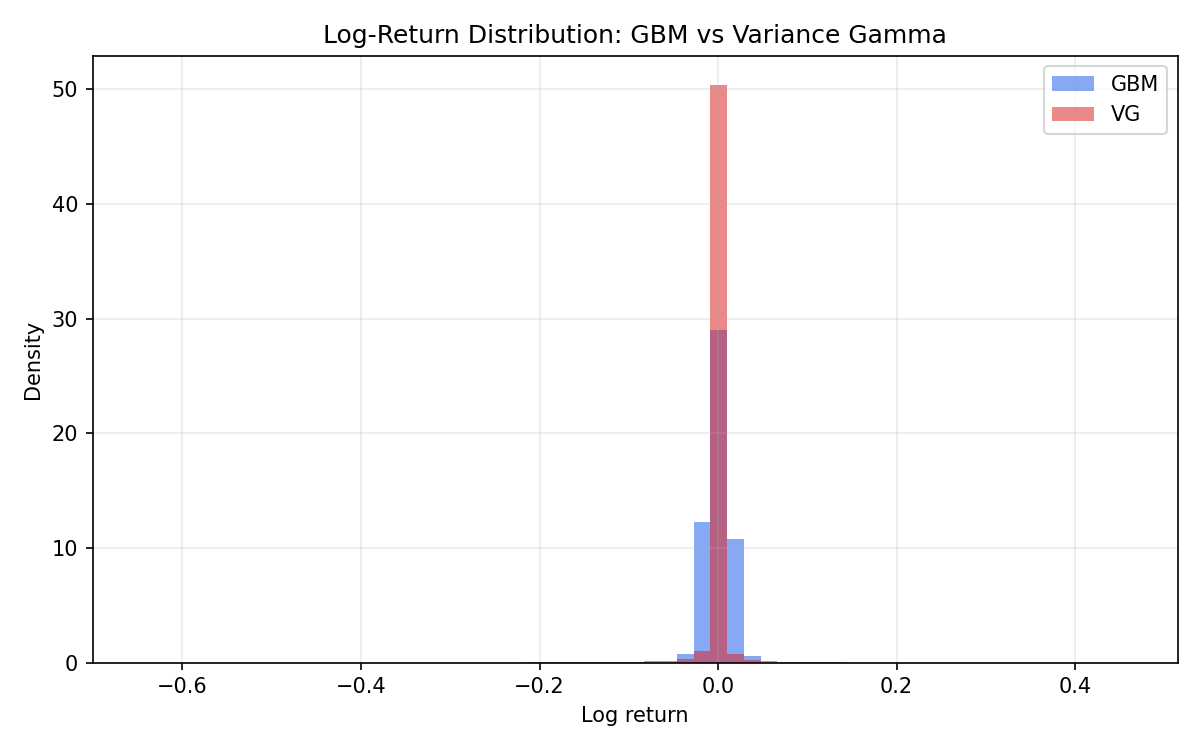

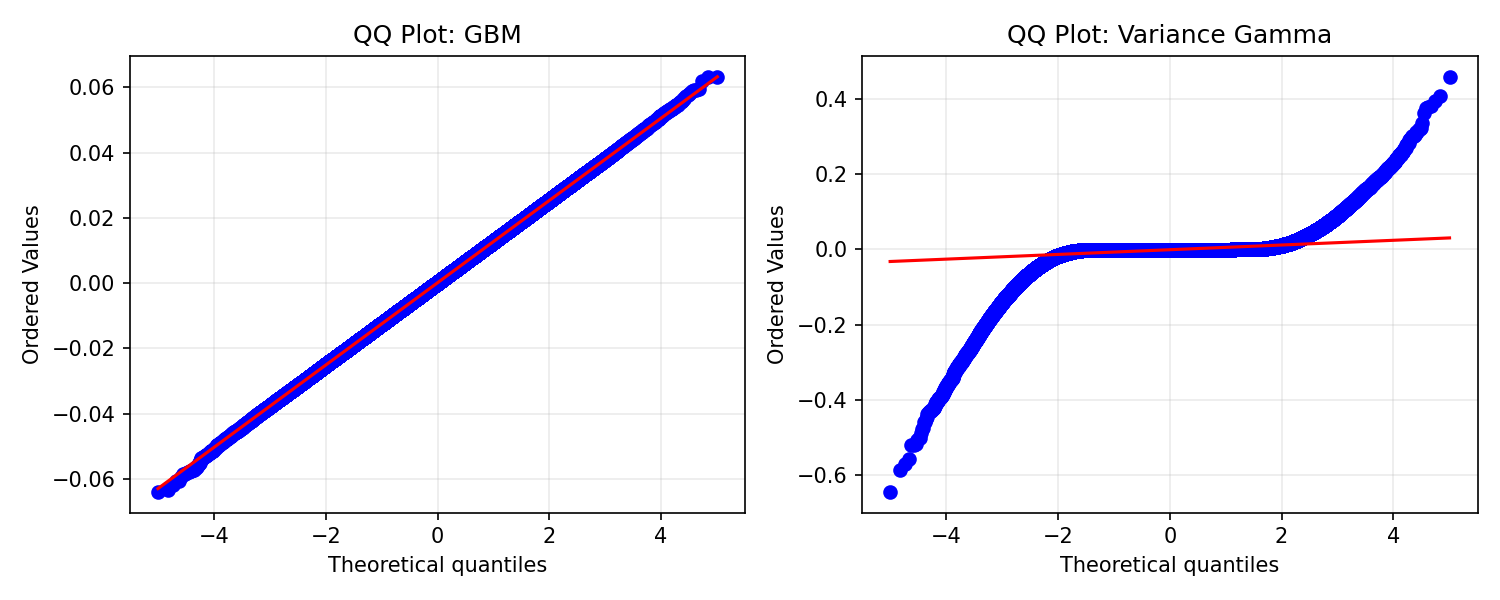

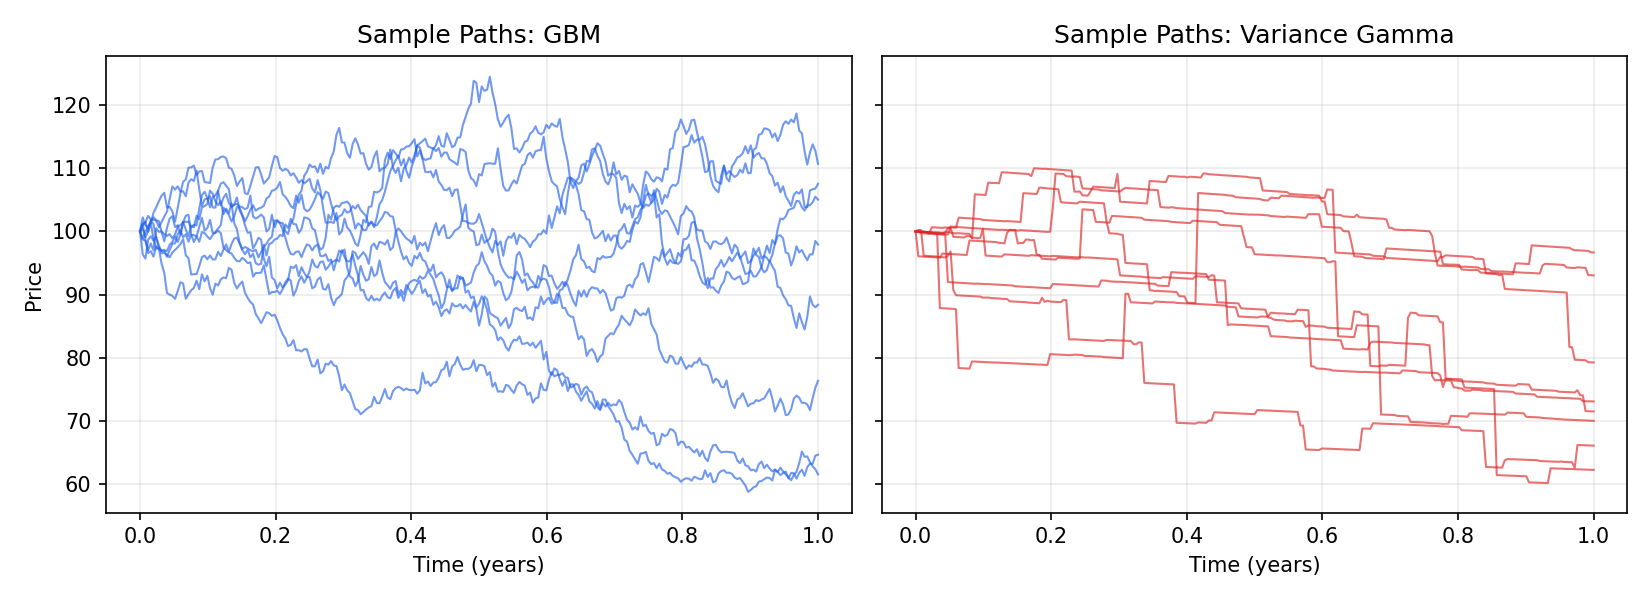

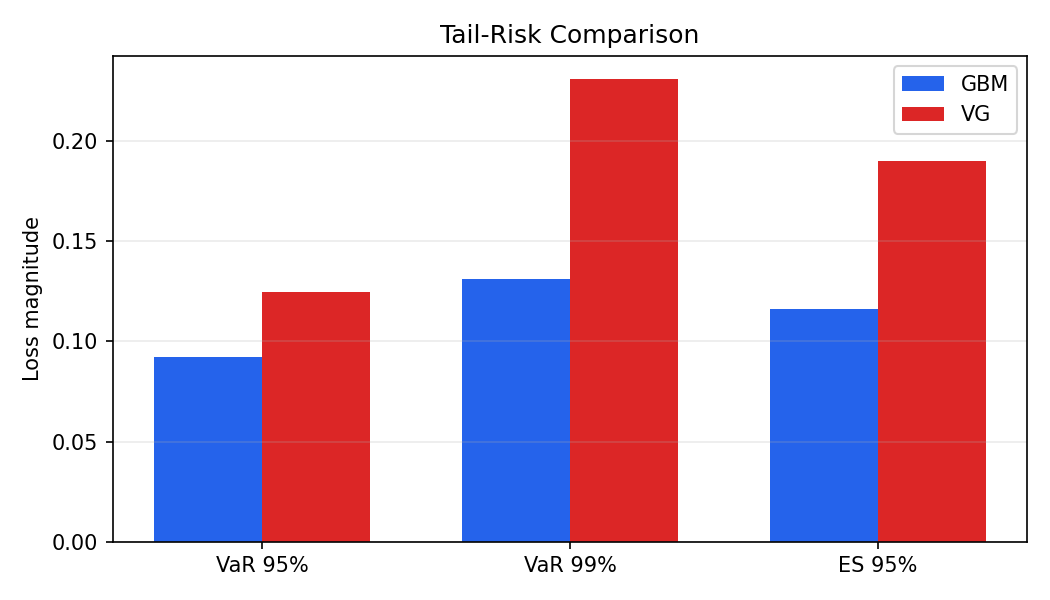

In [5]:
from IPython.display import Image, display

for path in figure_paths.values():
    display(Image(filename=str(path)))

## Interpretation

Under matched drift and volatility, GBM **underestimates crash risk** because it cannot generate the same frequency of large negative moves. VG's heavier left tail produces higher VaR and expected shortfall, which is critical when training or evaluating RL agents in simulated markets.

The **VG vs S&P 500** plot overlays simulated VG daily log-returns on historical index returns (`^GSPC`, 2010--present). Parameters are illustrative; systematic calibration to institutional data is the natural next step.

**Next steps:** calibrate VG/CGMY/Meixner parameters to institutional data, wrap the simulator in a Gymnasium trading environment, and study explainability methods for agent decisions under jump risk.